# Introduction to pointcloud & Deepset

In [40]:
import torch#, torchvision, torchmetrics
import torch.utils.data as data
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import numpy as np

In [41]:
from torchvision import datasets, transforms

In [42]:
import matplotlib.pyplot as plt

In [43]:
transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.,), (1.0,))
        ])

dataset = datasets.MNIST('./data', train=True, download=False,transform=transform)

In [44]:
if(torch.backends.cuda.is_built()) :
    device='cuda'
elif(torch.backends.mps.is_built()) :
    device='mps'
else :
    device='cpu'

In [45]:
X,y = dataset[12]

In [46]:
img_array = X[0]
torch.argwhere(img_array > 0.)[:,0]/img_array.shape[0]

tensor([0.1786, 0.1786, 0.1786, 0.1786, 0.1786, 0.1786, 0.1786, 0.1786, 0.1786,
        0.1786, 0.1786, 0.1786, 0.1786, 0.2143, 0.2143, 0.2143, 0.2143, 0.2143,
        0.2143, 0.2143, 0.2143, 0.2143, 0.2143, 0.2143, 0.2143, 0.2143, 0.2143,
        0.2143, 0.2143, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500,
        0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500, 0.2500,
        0.2857, 0.2857, 0.2857, 0.2857, 0.2857, 0.2857, 0.2857, 0.2857, 0.2857,
        0.2857, 0.3214, 0.3214, 0.3214, 0.3214, 0.3214, 0.3571, 0.3571, 0.3571,
        0.3571, 0.3571, 0.3571, 0.3929, 0.3929, 0.3929, 0.3929, 0.3929, 0.3929,
        0.3929, 0.4286, 0.4286, 0.4286, 0.4286, 0.4286, 0.4286, 0.4286, 0.4286,
        0.4643, 0.4643, 0.4643, 0.4643, 0.4643, 0.4643, 0.4643, 0.4643, 0.4643,
        0.4643, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5357, 0.5357, 0.5357, 0.5357, 0.5357,
        0.5357, 0.5357, 0.5357, 0.5357, 

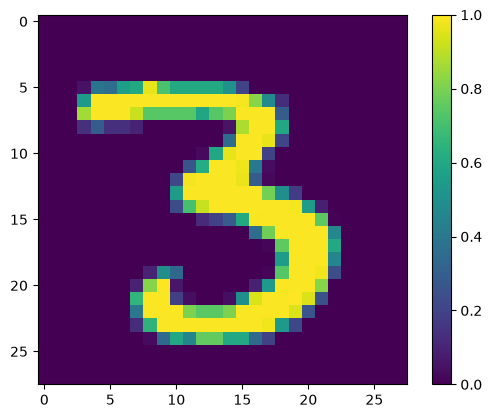

In [47]:
plt.imshow(X[0].numpy())
plt.colorbar()


In [48]:
# def transform_2d_img_to_point_cloud(data):

#     img, label = data
#     img_array = img[0]
#     values = img_array[img_array > 0]
#     x_coord = torch.argwhere(img_array > 0.)[:,0]/img_array.shape[0]
#     y_coord = torch.argwhere(img_array > 0.)[:,1]/img_array.shape[0]

#     return torch.stack( (x_coord, y_coord, values), dim=-1), label

In [49]:
#vect = transform_2d_img_to_point_cloudT(X)

In [50]:
class MNISTPC_Dataset(data.Dataset):

    def __init__(self, dataset_path:str, train:bool = True, download:bool =False, mean:float = 0., std:float = 1.) -> None:
        """
        self is used to refer to the instance of the class. It allows us to access the attributes and methods of the class in Python without getting deleted.
        Inputs:
            size - Number of data points we want to generate
            std - Standard deviation of the noise (see generate_continuous_xor function)
        """
        # calls the setup (initialization) routine of the "parent" class
        super().__init__()

        self.transform = transforms.Compose(
                       [
                        transforms.ToTensor(),
                        # normalize the tensor data by a certain mean and standard deviation. This is a common practice in deep learning to help with convergence.
                        transforms.Normalize((mean,), (std,))
                       ]
                       )

        self.dataset = datasets.MNIST(dataset_path, train=train, download=download,
                       transform=self.transform)


        self.pc_dataset = [ self.transform_2d_img_to_point_cloud(self.dataset[idx]) for idx in range(len(self.dataset)) ]


    def transform_2d_img_to_point_cloud(self, data_i:tuple) -> dict :

        img, label = data_i
        img_array = img[0]
        values = img_array[img_array > 0]
        x_coord = torch.argwhere(img_array > 0.)[:,0]/img_array.shape[0]
        y_coord = torch.argwhere(img_array > 0.)[:,1]/img_array.shape[0]

        point_vec = torch.stack( (x_coord, y_coord, values), dim=-1)

        return {'point' : point_vec, 'label' : label, 'seq_length' : len(point_vec)}


    def __len__(self) -> int:
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return len(self.pc_dataset)

    def __getitem__(self, idx:int) -> dict :
        # Return the idx-th data point of the dataset

        return self.pc_dataset[idx]#data_point, data_label


In [51]:
pc_dataset = MNISTPC_Dataset('./data/')

In [52]:
pc_dataset[19]

{'point': tensor([[0.2500, 0.4643, 0.0706],
         [0.2500, 0.5000, 0.4118],
         [0.2500, 0.5357, 0.8902],
         [0.2500, 0.5714, 0.9922],
         [0.2500, 0.6071, 0.9922],
         [0.2500, 0.6429, 0.4784],
         [0.2857, 0.4286, 0.2235],
         [0.2857, 0.4643, 0.7804],
         [0.2857, 0.5000, 0.9922],
         [0.2857, 0.5357, 0.9882],
         [0.2857, 0.5714, 0.9882],
         [0.2857, 0.6071, 0.9882],
         [0.2857, 0.6429, 0.9882],
         [0.2857, 0.6786, 0.6235],
         [0.3214, 0.3929, 0.0784],
         [0.3214, 0.4286, 0.8275],
         [0.3214, 0.4643, 0.9882],
         [0.3214, 0.5000, 0.9098],
         [0.3214, 0.5357, 0.5961],
         [0.3214, 0.5714, 0.2863],
         [0.3214, 0.6071, 0.6549],
         [0.3214, 0.6429, 0.9882],
         [0.3214, 0.6786, 0.8431],
         [0.3214, 0.7143, 0.0235],
         [0.3571, 0.3929, 0.7725],
         [0.3571, 0.4286, 0.9882],
         [0.3571, 0.4643, 0.7137],
         [0.3571, 0.6071, 0.1451],
         [0

In [53]:
def visualize_samples(data, label, marker='o'):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()

    plt.figure(figsize=(4,4))
    plt.scatter(data[:,0] , data[:,1], edgecolor="#333", marker=marker, label="Class " + str(label))

    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

In [54]:
pc, label = pc_dataset[19]['point'], pc_dataset[19]['label']

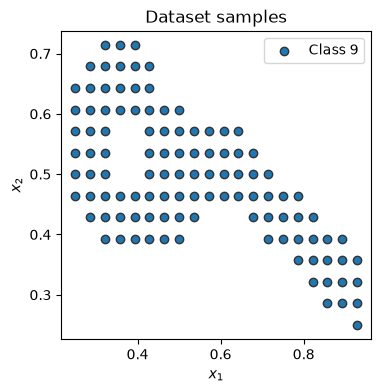

In [55]:
visualize_samples(pc, label)

In [56]:
# This function acts as a collator to combine a list of varying-sized point clouds into a single, uniform batch
def create_batch(data_list: list) -> tuple:

    # Look through all the point clouds in this specific batch and find the one with the highest number of points (seq_length)
    max_length = np.max([data_list[idx]["seq_length"] for idx in range(len(data_list))])

    # Initialize two empty lists to temporarily hold our newly padded point clouds and their corresponding labels
    pc_list, label_list = [], []

    # Loop through each item (dictionary) in the provided data batch
    for idx in range(len(data_list)):
        # Extract the raw point cloud tensor and the category label for the current item
        pc, label = data_list[idx]["point"], data_list[idx]["label"]

        # Get the number of actual points (N) and the number of features per point (C, like x, y, brightness)
        N, C = pc.shape[0], pc.shape[1]

        # Create a new blank "canvas" tensor filled entirely with zeros.
        # Its size is set to match the largest point cloud in the batch (max_length)
        pc_padded = torch.zeros([1, max_length, C])

        # Reshape the original point cloud to add a temporary "batch" dimension of 1 at the beginning
        # This changes the shape from (N, C) to (1, N, C)
        pc = pc.reshape(1, N, C)

        # Paste the real points into the beginning of the zero-filled canvas.
        # Any remaining space at the end stays as zeros, which acts as our dummy padding.
        pc_padded[:, 0:N, :] = pc[:, :, :]

        # Add the successfully padded point cloud to our holding list
        pc_list.append(pc_padded)

        # Convert the integer label into a PyTorch tensor and add it to our label list
        label_list.append(torch.tensor([label]))

    # Finally, glue all the individual padded point clouds together along the batch dimension (dim=0) to make one massive 3D tensor.
    # Do the exact same thing to combine all the labels into a 1D tensor, and return both.
    return torch.cat(pc_list, dim=0), torch.cat(label_list, dim=0)


In [57]:
type(pc_dataset)

__main__.MNISTPC_Dataset

In [58]:
pc_dataloader = data.DataLoader(dataset=pc_dataset, batch_size=5, shuffle=True, collate_fn=create_batch)

In [59]:
pc_chunk, label_chunk = next(iter(pc_dataloader))

In [60]:
pc_chunk.shape, label_chunk.shape

(torch.Size([5, 166, 3]), torch.Size([5]))

# Define the basic deepset layer

A permutation equivariant layer is defined as 
$$ 
x' = \Theta. x \equiv \gamma \mathbb{I}.x + \lambda (\mathbb{I} \mathbb{I}^T) . x~~~\lambda \,, \gamma \in \mathbb{R}
$$ 

Assuming $x = (x_1, x_2, x_3)^T$, the above equation becomes : 
$$
\begin{pmatrix}
x_1' \\
x_2' \\
x_3' 
\end{pmatrix}
= \gamma 
\begin{pmatrix}
1 && 0 && 0 \\
0 && 1 && 0 \\
0 && 0 && 1
\end{pmatrix} 
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix} + 
\lambda
\begin{pmatrix}
1 && 1 && 1 \\
1 && 1 && 1 \\
1 && 1 && 1
\end{pmatrix}  
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix} \\ \\
= 
\begin{pmatrix}
(\gamma + \lambda)x_1 + \lambda(x_2 + x_3)\\
(\gamma + \lambda)x_2 + \lambda(x_1 + x_3) \\
(\gamma + \lambda)x_3 + \lambda(x_1 + x_2) 
\end{pmatrix} \\ \\
= (\gamma + \lambda)
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix}
- \lambda
\begin{pmatrix}
x_1 - \sum x_i\\
x_2 - \sum x_i\\
x_3 - \sum x_i
\end{pmatrix}
= \Gamma .x + \Lambda.\Big(x - \alpha(x) \Big)
$$


In [ ]:
# Create a new custom neural network layer that inherits from PyTorch's standard building block (nn.Module)
class DeepSetLayer(nn.Module):
    # The setup function that runs when you first create this layer.
    # It takes the size of the inputs, the desired size of the outputs, and your preferences for normalization and pooling.
    def __init__(
        self,
        in_features: int,
        out_features: int,
        normalization: str = "",
        pool: str = "mean",
    ) -> None:
        """
        DeepSets single layer
        ... (docstring ignored for brevity) ...
        """
        # Run PyTorch's required background setup so this layer plays nicely with the rest of the NN framework
        super(DeepSetLayer, self).__init__()

        # Create the 'Gamma' transformation: a standard math layer (Linear) that will process points individually
        self.Gamma = nn.Linear(in_features, out_features)

        # Create the 'Lambda' transformation: a second math layer that will process the point's relationship to the group
        self.Lambda = nn.Linear(in_features, out_features)

        # Save the choices for normalization and pooling as internal variables so we can use them later
        self.normalization = normalization
        self.pool = pool

        # Check if the requested 'batchnorm' (a common technique to keep numbers from getting too big or small during training)
        if normalization == "batchnorm":
            # Create a 1D Batch Normalization layer sized to match our output
            self.bn = nn.BatchNorm1d(out_features)

    # The 'forward' function defines the actual journey the data takes through the layer
    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # The input data 'x' is shaped like a 3D box: (Batch Size, Number of Points, Features)

        if self.pool == "mean":
            # 1. x.mean(dim=1) calculates the average of all points.
            # 2. (x - x.mean()) calculates the difference between the current point and the group average.
            # 3. We pass the individual point through Gamma, pass the difference through Lambda, and add them together.
            x = self.Gamma(x) + self.Lambda(x - x.mean(dim=1, keepdim=True))

        # Or, if it's decided to summarize the group using the single highest value ('max')...
        elif self.pool == "max":
            # We do the exact same calculation, but we subtract the 'maximum' value instead of the average.
            x = self.Gamma(x) + self.Lambda(x - x.max(dim=1, keepdim=True))

        # Check if we turned on batch normalization during the setup phase
        if self.normalization == "batchnorm":
            # Process the newly calculated points through the normalizer to stabilize the math
            x = self.bn(x)

        # Spit out the final updated point cloud to be used by the next layer
        return x

In [62]:
ds_layer = DeepSetLayer(in_features = 3, out_features = 4)

In [63]:
y = ds_layer(pc_chunk)

In [64]:
pc_chunk.shape, y.shape

(torch.Size([5, 166, 3]), torch.Size([5, 166, 4]))

## Make the full deepset model as stack of Deepset layers and non-linear activation functions

In [ ]:
# Create the full DeepSet model, inheriting from PyTorch's standard neural network module
class DeepSet(nn.Module):
    # The setup function takes the input size, a list of hidden layer sizes ('feats'),
    # the number of final categories to predict ('n_class'), and the settings for normalization/pooling.
    def __init__(
        self,
        in_features: int,
        feats: list,
        n_class: int,
        normalization: str = "",
        pool: str = "mean",
    ) -> None:
        """
        DeepSets implementation
        ... (docstring ignored for brevity) ...
        """
        # Run PyTorch's standard background setup
        super(DeepSet, self).__init__()

        # Create an empty standard Python list to temporarily hold our layers as we build them
        layers = []

        # Build the VERY FIRST layer. It takes the raw input data (in_features)
        # and transforms it to the size of the first hidden layer (feats[0]).
        layers.append(
            DeepSetLayer(
                in_features=in_features,
                out_features=feats[0],
                normalization=normalization,
                pool=pool,
            )
        )

        # Loop through the rest of the sizes provided in the 'feats' list
        for i in range(1, len(feats)):
            # Add a ReLU activation function. This adds "non-linearity" (allowing the NN to learn complex, curved patterns instead of just straight lines)
            layers.append(nn.ReLU())

            # Add the NEXT DeepSet layer, connecting the previous size (feats[i-1]) to the current size (feats[i])
            layers.append(
                DeepSetLayer(
                    in_features=feats[i - 1],
                    out_features=feats[i],
                    normalization=normalization,
                    pool=pool,
                )
            )

        # Build the VERY LAST layer. It takes the final hidden size (feats[-1])
        # and outputs the exact number of categories we want to predict (n_class).
        layers.append(
            DeepSetLayer(
                in_features=feats[-1],
                out_features=n_class,
                normalization=normalization,
                pool=pool,
            )
        )

        # We can't leave the layers in a standard Python list, because PyTorch won't "see" them to train them.
        # We wrap the list in 'nn.ModuleList' to officially register all these layers into the NN's brain.
        self.sequential = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Loop through every single layer and activation function in our ModuleList one by one
        for i, layer in enumerate(self.sequential):
            # Overwrite 'x' with the output of the current layer, passing it down the chain
            x = layer(x)

        # At this point, 'x' still has data for every individual point in the cloud.
        # x.mean(dim=1) averages ALL the points together into one single, global "summary" vector for the whole cloud.
        x = x.mean(dim=1)  # -- average over the points -- #

        # Finally, we apply a 'log_softmax' mathematical function.
        # This converts the raw, unbound output numbers into proper probabilities (which sum to 100%),
        # but kept in a logarithmic format because it makes the training math more stable.
        out = F.log_softmax(x, dim=-1)

        # Output the final guess (e.g., an array of probabilities for digits 0-9)
        return out

In [66]:
model = DeepSet(in_features=3, feats=[5, 9, 12, 16, 13], n_class=10)
model = model.to(device)

In [67]:
y = model(pc_chunk.to(device))

In [68]:
y.shape, label_chunk.shape

(torch.Size([5, 10]), torch.Size([5]))

In [69]:
F.nll_loss(input=y, target=label_chunk.to(device))

tensor(2.2518, device='mps:0', grad_fn=<NllLossBackward0>)

In [70]:
torch.backends.mps.is_built()

True

In [71]:
device

'mps'

## creating the training block

In [ ]:
# Define the training function that updates the NN's knowledge over one full pass (epoch) of the dataset
def train(model, device, train_loader, optimizer):

    # Initialize a running total to track the overall error (loss) for this entire epoch
    train_loss_ep = 0.0

    # Put the model into 'training mode'
    # This officially turns on specific learning features like dropout or batch normalization tracking
    model.train()

    # Loop through the data loader, which serves up our data in pre-packaged batches
    for batch_idx, (data, target) in enumerate(train_loader):
        # Send the batch's data and the correct answers (targets) to the active processor (CPU or GPU)
        data, target = data.to(device), target.to(device)

        # Wipe away the math gradients (learning signals) calculated from the previous batch
        # If we don't do this, PyTorch will add the new gradients on top of the old ones, ruining the math
        optimizer.zero_grad()

        # Forward pass: Ask the model to look at the data and make its best predictions
        output = model(data)

        # Calculate the "Negative Log Likelihood Loss"
        # This function measures exactly how far off the model's predictions were from the true targets
        loss = F.nll_loss(output, target)

        # Backward pass (Backpropagation):
        # Mathematically calculate how much each internal weight in the network contributed to the error
        loss.backward()

        # Optimizer step:
        # Physically adjust the model's internal weights based on the calculations above to reduce the error next time
        optimizer.step()

        # Add this batch's total loss to our running sum
        # loss.item() gives the average error, so we multiply it by data.size(0) (the batch size) to get the absolute total
        train_loss_ep += loss.item() * data.size(0)

    # Return the accumulated error for the entire training pass
    return train_loss_ep


## create the testing block

In [73]:
def test(model, device, test_loader):

    test_loss_ep = 0.

    model.eval()
    for batch_idx, (data, target) in enumerate(test_loader):
        data, target = data.to(device), target.to(device)

        output = model(data)
        loss = F.nll_loss(output, target)

        test_loss_ep += loss.item() * data.size(0)

    return test_loss_ep

# Let's prepare the full dataset and dataloaders

In [74]:
# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 5
# percentage of training set to use as validation
valid_size = 0.2
# # convert data to torch.FloatTensor
# transform = transforms.ToTensor()
# choose the training and testing datasets
train_data =  MNISTPC_Dataset('./data/', train = True, download = True)
test_data = MNISTPC_Dataset('./data/', train = False, download = True)
# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_index, valid_index = indices[split:], indices[:split]
# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_index)
valid_sampler = SubsetRandomSampler(valid_index)
# prepare data loaders
train_loader = data.DataLoader(dataset=train_data, batch_size = batch_size,
                                           num_workers = num_workers, sampler = train_sampler, collate_fn=create_batch)
valid_loader = data.DataLoader(train_data, batch_size = batch_size,
                                          num_workers = num_workers,  sampler = valid_sampler, collate_fn=create_batch)
test_loader = data.DataLoader(test_data, batch_size = batch_size,
                                                     num_workers = num_workers, shuffle=False, collate_fn=create_batch)


In [75]:
model = model.to(device=device)

In [76]:
optimizer = torch.optim.SGD(model.parameters(),lr = 0.01)

## Run the training loop 

In [77]:
# number of epochs to train the model
n_epochs = 20
# initialize tracker for minimum validation loss
valid_loss_min = np.inf  # set initial "min" to infinity
for epoch in range(n_epochs):
    # monitor losses

    train_loss = train(model, device, train_loader, optimizer)

    valid_loss = test(model, device, valid_loader)

    # print training/validation statistics
    # calculate average loss over an epoch
    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch+1,
        train_loss,
        valid_loss
        ))

    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 2.302346 	Validation Loss: 2.299989
Validation loss decreased (inf --> 2.299989).  Saving model ...
Epoch: 2 	Training Loss: 2.203720 	Validation Loss: 2.036428
Validation loss decreased (2.299989 --> 2.036428).  Saving model ...
Epoch: 3 	Training Loss: 2.016045 	Validation Loss: 1.962049
Validation loss decreased (2.036428 --> 1.962049).  Saving model ...
Epoch: 4 	Training Loss: 1.881460 	Validation Loss: 1.735217
Validation loss decreased (1.962049 --> 1.735217).  Saving model ...
Epoch: 5 	Training Loss: 1.668555 	Validation Loss: 2.103373
Epoch: 6 	Training Loss: 1.323886 	Validation Loss: 1.105094
Validation loss decreased (1.735217 --> 1.105094).  Saving model ...
Epoch: 7 	Training Loss: 0.923362 	Validation Loss: 0.738394
Validation loss decreased (1.105094 --> 0.738394).  Saving model ...
Epoch: 8 	Training Loss: 0.688765 	Validation Loss: 0.559505
Validation loss decreased (0.738394 --> 0.559505).  Saving model ...
Epoch: 9 	Training Loss: 0.553650 

## Load the best saved model and use it for test performance

In [78]:
model_test = DeepSet(in_features=3, feats=[5, 9, 12, 16, 13], n_class=10)
model_test.load_state_dict(torch.load('model.pt'))
model_test.to(device)



DeepSet(
  (sequential): ModuleList(
    (0): DeepSetLayer(
      (Gamma): Linear(in_features=3, out_features=5, bias=True)
      (Lambda): Linear(in_features=3, out_features=5, bias=True)
    )
    (1): ReLU()
    (2): DeepSetLayer(
      (Gamma): Linear(in_features=5, out_features=9, bias=True)
      (Lambda): Linear(in_features=5, out_features=9, bias=True)
    )
    (3): ReLU()
    (4): DeepSetLayer(
      (Gamma): Linear(in_features=9, out_features=12, bias=True)
      (Lambda): Linear(in_features=9, out_features=12, bias=True)
    )
    (5): ReLU()
    (6): DeepSetLayer(
      (Gamma): Linear(in_features=12, out_features=16, bias=True)
      (Lambda): Linear(in_features=12, out_features=16, bias=True)
    )
    (7): ReLU()
    (8): DeepSetLayer(
      (Gamma): Linear(in_features=16, out_features=13, bias=True)
      (Lambda): Linear(in_features=16, out_features=13, bias=True)
    )
    (9): DeepSetLayer(
      (Gamma): Linear(in_features=13, out_features=10, bias=True)
      (Lam

In [ ]:
# Define a function to grade the model's accuracy on a given dataset
def eval_model(model, data_loader):

    # Lock the model into evaluation mode.
    # This explicitly disables training behaviors (like dropout) to ensure consistent answers.
    model.eval()

    # Initialize two counters: one for the number of correct guesses, and one for total guesses made.
    true_preds, num_preds = 0.0, 0.0

    # Temporarily turn off PyTorch's gradient tracking (the math used to update the NN's brain).
    # This saves significant memory and processing power since we are only testing, not learning.
    with torch.no_grad():
        # Loop through the data loader, pulling out batches of inputs and their correct labels
        for data_inputs, data_labels in data_loader:
            # Send the input data and the correct labels to the active processor (CPU or GPU)
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)

            # Ask the model to look at the inputs and generate its raw predictions (logits)
            preds = model(data_inputs)

            # These lines would be used if we were doing
            # a simple binary Yes/No classification using a sigmoid curve.
            # preds = preds.squeeze(dim=1)
            # preds = torch.sigmoid(preds)

            # Look at the predicted probabilities across all categories.
            # torch.argmax finds the category index with the highest probability score and locks it in as the final guess.
            pred_labels = torch.argmax(preds, dim=-1)

            # Compare the model's final guesses against the true labels.
            # A match equals 1, a miss equals 0. We sum these up to get the total correct guesses in this batch.
            true_preds += (pred_labels == data_labels).sum()

            # Add the total number of items in this batch to our running total of predictions made.
            num_preds += data_labels.shape[0]

    # Calculate the overall accuracy ratio by dividing the correct guesses by the total guesses.
    acc = true_preds / num_preds

    # Print the final result, formatted as a percentage with exactly two decimal places.
    print(f"Accuracy of the model: {100.0 * acc:4.2f}%")

In [80]:
eval_model(model_test, test_loader)

Accuracy of the model: 91.66%


In [81]:
# for child in model.children():
#    print(" child : ",child)